<center><img src="img/banner.jpeg" width=1200px /></center>

<center><h1><b><span style="color: green">Translational Neuroscience School 2026</b></span></h1></center>

# <span style="color: red;">Taller de Análisis de Datos.</span>
## <span style="color: red;"> Psic. Rodrigo Cáceres Robles </span>
## Datos electrofisiológicos de: <span style="color: blue;">*Fear conditioning potentiates the hippocampal CA1 commissural pathway in vivo and increases awake phase sleep*</span>

---

### <span style="color: red;">Acerca de este taller</span>

Este taller está diseñado para aprender y practicar herramientas de Python utilizando registros electrofisiológicos reales obtenidos de ratones en libre movimiento. Los datos y análisis que exploraremos provienen del estudio publicado por Subramaniyan et al. (2021) en la revista *Hippocampus* (DOI: [10.1002/hipo.23381](https://doi.org/10.1002/hipo.23381)).

<center> <img src="img/hipo.v31.2.cover.jpg" width=200px /> </center>

Trabajar con datos reales nos permite enfrentarnos a los mismos problemas que encuentra un investigador: Ruido en las señales, variables de confusión, etc.

---

### <span style="color: red;">Contexto del estudio</span>

El hipocampo es una estructura cerebral esencial para el aprendizaje espacial y la formación de memorias. En este estudio, los autores investigaron si el aprendizaje asociativo produce cambios medibles en la fuerza sináptica de la vía comisural que conecta las regiones CA1 del hipocampo izquierdo y derecho.

Para ello, utilizaron un paradigma de condicionamiento contextual de miedo (cFC), en el que los ratones aprenden a asociar un contexto (la cámara de condicionamiento) con un estímulo aversivo (descargas eléctricas en las patas). Este tipo de aprendizaje ocurre en un solo ensayo de ~5 minutos, y como veremos provocará cambios medibles en la fuerza sináptica.

<center> <img src="img/articulo-e1.png" width=400px /> </center>
<span style="color: blue;"><center><b>Figura 1e </b> </center></span>

#### <span style="color: red;">¿Cómo midieron la fuerza sináptica?</span>

Los investigadores implantaron electrodos en el hipocampo dorsal de ratones:
- Un electrodo de estimulación en la región CA1 izquierda.
- Uno o más electrodos de registro en la región CA1 derecha.
<center> <img src="img/articulo-b1.png" width=400px /> </center>
<span style="color: blue;"><center><b>Figura 1b </b> </center></span>

La fuerza sináptica se cuantificó midiendo la pendiente de los potenciales postsinápticos excitatorios de campo (fEPSP), que refleja la eficacia de la transmisión sináptica en la vía comisural. Se aplicaron pulsos de estimulación cada 60 segundos durante 2 horas antes (línea base) y 3 horas después del condicionamiento.
<center> <img src="img/Radahmadi-2c.png" width=400px /> </center>
<span style="color: blue;"><center><b>Radahmadi et. al. (2025). Figura 2c. </b> </center></span>


#### <span style="color: red;">Principales hallazgos</span>

1. Después del condicionamiento de miedo, la fuerza sináptica de la vía comisural aumentó significativamente, lo que indica LTP in vivo asociada al aprendizaje.
2. Aunque los experimentos se realizaron durante la fase oscura (fase activa), los ratones durmieron más después del condicionamiento, con predominio de sueño NREM.
3. Durante el sueño NREM, las respuestas sinápticas fueron mayores que durante la vigilia, actuando como una modulación de ganancia multiplicativa
---

### <span style="color: red;">Objetivos del taller</span>

En este taller aprenderemos a:

1. Cargar y explorar datos electrofisiológicos y de comportamiento.
2. Visualizar series temporales de pendientes de fEPSP antes y después del condicionamiento.
3. Manipular y realizar operaciones con arreglos numéricos
4. Aplicar pruebas estadísticas para evaluar cambios pre vs. post-condicionamiento, incluyendo modelos lineales mixtos.
5. Controlar variables de confusión (sueño y velocidad) en la estimación de los efectos del aprendizaje.

---

### <span style="color: red;">Datos</span>

Los datos originales (en formato de MATLAB, .mat) asociados a este estudio están disponibles públicamente en el repositorio Dryad:

> **DOI:** [10.5061/dryad.sj3tx965f](https://doi.org/10.5061/dryad.sj3tx965f)

---

### <span style="color: red;">Herramientas que utilizaremos</span>

In [1]:
import numpy as np          
import matplotlib.pyplot as plt  
import scipy.signal as signal    
import scipy.stats as stats
from IPython.display import HTML

### <span style="color: red;">Estructura del taller</span>

| Sección | Tema | Herramientas |
|---------|------|-------------------|
| 1 | Carga y exploración de datos | `scipy`, `numpy` |
| 2 | Visualización de series temporales de fEPSP | `matplotlib` |
| 3 | Extracción de características de fEPSP | `numpy` |
| 3 | Análisis estadísticos | `scipy.stats`, correlación de medidas repetidas |
| 4 | Estimación de potenciación y depresión sináptica | Modelos lineales mixtos |

---

### <span style="color: red;">Referencias</span>
- Radahmadi M, Halabian A, Halabian A. An overview of extracellular field potentials: Different potentiation and measurable components, interpretations, and hippocampal synaptic activity models. Methods. 2025 Jul;239:50-63. https://doi.org/10.1016/j.ymeth.2025.03.015. 
- Subramaniyan, M., Manivannan, S., Chelur, V., Tsetsenis, T., Jiang, E., & Dani, J. A. (2021). Fear conditioning potentiates the hippocampal CA1 commissural pathway in vivo and increases awake phase sleep. *Hippocampus*, 31(10), 1154–1175. https://doi.org/10.1002/hipo.23381

---



<center><h1><span style="color: red;">¡Comencemos!!!..??</span></h1></center>
<center> <img src="img/gato_113255-209876.jpg" width=300px /> </center>
                                 

<center><h1><span style="color: green;">...Noo, antes repasemos rápidamente algunos puntos básicos.</span></h1></center>
<center> <img src="img/thinking-cat-douglas-sacha.jpg" width=300px /> </center>

# <span style="color: red;">A. Aprendiendo / recordando datos y estructuras básicas <span style="color: red;">

Cuando trabajamos con datos experimentales, rara vez manejamos un solo valor. Normalmente tenemos colecciones de datos: una serie de mediciones, los nombres de los sujetos experimentales, las condiciones de cada grupo, etc. Python nos ofrece varias estructuras para organizar estos conjuntos de datos. Las dos más fundamentales son las listas y los diccionarios.

## <span style="color: red;"> 1. Listas <span style="color: red;">
Una lista es una colección ordenada de elementos. Se define usando corchetes `[]` y los elementos se separan por comas. Las listas pueden contener cualquier tipo de dato: números, texto, otras listas, e incluso mezclas de todos ellos.

In [2]:
# Una lista con los nombres de ratas de laboratorio
ratas = ["Bigotes", "Canela", "Pelusa", "Trueno", "Manchas"]

print(ratas)

['Bigotes', 'Canela', 'Pelusa', 'Trueno', 'Manchas']


In [3]:
# Una lista de números (pesos en gramos)
pesos = [280.5, 310.2, 260.8, 330.1, 290.4]
 
print(pesos)

[280.5, 310.2, 260.8, 330.1, 290.4]


In [4]:
# Una lista mixta (aunque no es lo más común)
datos_mixtos = ["Bigotes", 28.5, True, 3]

print(datos_mixtos)

['Bigotes', 28.5, True, 3]


### <span style="color: red;"> 1.1. Indexación </span>
Cada elemento de una lista tiene una posición o índice. En Python, los índices comienzan en 0, no en 1. Esto es muy importante y es fuente frecuente de errores al principio.

In [5]:
ratas = ["Bigotes", "Canela", "Pelusa", "Trueno", "Manchas"]
#  Índice: 0,1,2,3,4

In [6]:
# Acceder al primer elemento (índice 0)
print(ratas[0])

Bigotes


---


<p>
  <img src="img/cat_dancing.gif"
       width="60"
       height="60"
       style="border-radius: 50%; object-fit: cover; border: 1px solid blue;" />
  <span style="color: blue; font-size: 40px;">Ejercicio</span>
</p>

In [7]:
# ¿Como acceder al tercer elemento?
print(ratas[2])

Pelusa


---

In [8]:
# Acceder al último elemento usando índices negativos
print(ratas[-1])

Manchas


Nota: Los índices negativos cuentan desde el final de la lista. `-1` es el último elemento, `-2` el penúltimo, y así sucesivamente

### <span style="color: red;">  1.2. Slicing </span>
Podemos extraer sublistas usando la notación `lista[inicio:fin]`. El elemento en la posición `inicio` se incluye, pero el de la posición `fin` no se incluye.

In [9]:
ratas = ["Bigotes", "Canela", "Pelusa", "Trueno", "Manchas"]

In [10]:
# Las primeras tres ratas (índices 0, 1, 2)
print(ratas[0:3])

['Bigotes', 'Canela', 'Pelusa']


---


<p>
  <img src="img/cat_dancing.gif"
       width="60"
       height="60"
       style="border-radius: 50%; object-fit: cover; border: 1px solid blue;" />
  <span style="color: blue; font-size: 40px;">Ejercicio</span>
</p>

In [11]:
# ¿Como obtener desde la segunda hasta el final
print(ratas[1:])

['Canela', 'Pelusa', 'Trueno', 'Manchas']


---

In [12]:
# Las dos últimas ratas
print(ratas[-2:])

['Trueno', 'Manchas']


### <span style="color: red;"> 1.3. Operaciones útiles con listas: </span>

In [13]:
pesos = [280.5, 310.2, 260.8, 330.1, 290.4]

In [14]:
# Valor mínimo y máximo
print("Peso mínimo:", min(pesos))
print("Peso máximo:", max(pesos))

Peso mínimo: 260.8
Peso máximo: 330.1


In [15]:
pesos_ordenados = sorted(pesos)
print("Pesos ordenados:", pesos_ordenados)

Pesos ordenados: [260.8, 280.5, 290.4, 310.2, 330.1]


In [16]:
# Verificar si un elemento está en la lista
print("¿Está Canela en la lista?", "Canela" in ratas)
print("¿Está Trueno en la lista?", "Trueno" in ratas)

¿Está Canela en la lista? True
¿Está Trueno en la lista? True


---


<p>
  <img src="img/cat_dancing.gif"
       width="60"
       height="60"
       style="border-radius: 50%; object-fit: cover; border: 1px solid blue;" />
  <span style="color: blue; font-size: 40px;">Ejercicio</span>
</p>

In [17]:
# ¿Puedes verificar si Pelusa está en la lista?
print("¿Está Pelusa en la lista?", "Pelusa" in ratas)

¿Está Pelusa en la lista? True


---

## <span style="color: red;"> 2. Diccionarios <span style="color: red;">
Un diccionario es una colección de pares clave-valor. A diferencia de las listas, donde accedemos a los elementos por su posición numérica, en los diccionarios accedemos a los valores mediante una clave descriptiva. Se definen con llaves `{}`.
Podemos pensar en un diccionario como una ficha de identificación: cada campo (clave) tiene un dato asociado (valor).

### Creación de diccionarios

In [18]:
# Ficha de un animal de laboratorio
animal_01 = {
    "nombre": "Bigotes",
    "codigo":  "E1M0",
    "especie": "ratón",
    "cepa": "C57BL/6J",
    "peso_g": 28.5,
    "sexo": "macho",
    "implante": True
}
 
print(animal_01)

{'nombre': 'Bigotes', 'codigo': 'E1M0', 'especie': 'ratón', 'cepa': 'C57BL/6J', 'peso_g': 28.5, 'sexo': 'macho', 'implante': True}


### Acceder a los valores
 
Para obtener un valor, usamos la clave entre corchetes 

In [19]:
# Acceder al nombre del animal
print(animal_01["nombre"])

Bigotes


In [20]:
# Acceder a la especie
print(animal_01["especie"])

ratón


---


<p>
  <img src="img/cat_dancing.gif"
       width="60"
       height="60"
       style="border-radius: 50%; object-fit: cover; border: 1px solid blue;" />
  <span style="color: blue; font-size: 40px;">Ejercicio</span>
</p>

In [21]:
# ¿Como acceder al peso del animal 01?
print(animal_01["peso_g"])

28.5


---

### Modificar diccionarios
Los diccionarios también son mutables.

In [22]:
# Actualizar el peso después de una nueva medición
animal_01["peso_g"] = 29.1
print("Nuevo peso:", animal_01["peso_g"])

Nuevo peso: 29.1


---


<p>
  <img src="img/cat_dancing.gif"
       width="60"
       height="60"
       style="border-radius: 50%; object-fit: cover; border: 1px solid blue;" />
  <span style="color: blue; font-size: 40px;">Ejercicio</span>
</p>

In [23]:
# Actualiza el peso del animal 01 nuevamente, a 34 g
animal_01["peso_g"] = 34.0
print("Nuevo peso:", animal_01["peso_g"])

Nuevo peso: 34.0


---

In [24]:
# Agregar un campo nuevo
animal_01["grupo"] = "condicionado"
print(animal_01)

{'nombre': 'Bigotes', 'codigo': 'E1M0', 'especie': 'ratón', 'cepa': 'C57BL/6J', 'peso_g': 34.0, 'sexo': 'macho', 'implante': True, 'grupo': 'condicionado'}


---


<p>
  <img src="img/cat_dancing.gif"
       width="60"
       height="60"
       style="border-radius: 50%; object-fit: cover; border: 1px solid blue;" />
  <span style="color: blue; font-size: 40px;">Ejercicio</span>
</p>

In [25]:
# Agrega un campo de edad en meses y asigna un valor numerico
animal_01["edad_meses"] = 3.4
print(animal_01)

{'nombre': 'Bigotes', 'codigo': 'E1M0', 'especie': 'ratón', 'cepa': 'C57BL/6J', 'peso_g': 34.0, 'sexo': 'macho', 'implante': True, 'grupo': 'condicionado', 'edad_meses': 3.4}


---

### Explorar un diccionario

In [26]:
animal_01 = {
    "nombre": "Bigotes",
    "especie": "ratón",
    "cepa": "C57BL/6J",
    "edad_meses": 3.2,
    "peso_g": 28.5,
    "sexo": "macho"
}
 
# Ver todas las claves
print("Claves:", list(animal_01.keys()))
 
# Ver todos los valores
print("Valores:", list(animal_01.values()))
 
# Ver los pares clave-valor
print("Pares:", list(animal_01.items()))

Claves: ['nombre', 'especie', 'cepa', 'edad_meses', 'peso_g', 'sexo']
Valores: ['Bigotes', 'ratón', 'C57BL/6J', 3.2, 28.5, 'macho']
Pares: [('nombre', 'Bigotes'), ('especie', 'ratón'), ('cepa', 'C57BL/6J'), ('edad_meses', 3.2), ('peso_g', 28.5), ('sexo', 'macho')]


## <span style="color: red;"> 3. Combinando listas y diccionarios <span style="color: red;">

En la práctica, es muy común combinar estas estructuras. Por ejemplo, podemos tener una lista de diccionarios donde cada diccionario representa un animal del estudio.


In [27]:
sala_del_bioterio = [
    {
        "nombre": "Bigotes",
        "especie": "ratón",
        "cepa": "C57BL/6J",
        "edad_meses": 3.2,
        "peso_g": 28.5,
        "grupo": "condicionado"
    },
    {
        "nombre": "Canela",
        "especie": "rata",
        "cepa": "Wistar",
        "edad_meses": 4.1,
        "peso_g": 245.0,
        "grupo": "control"
    },
    {
        "nombre": "Pelusa",
        "especie": "ratón",
        "cepa": "C57BL/6J",
        "edad_meses": 2.9,
        "peso_g": 26.8,
        "grupo": "condicionado"
    },
    {
        "nombre": "Trueno",
        "especie": "rata",
        "cepa": "Sprague-Dawley",
        "edad_meses": 3.8,
        "peso_g": 310.5,
        "grupo": "control"
    }
]

In [28]:
# Acceder al segundo animal
print(sala_del_bioterio[1]["nombre"], "-", sala_del_bioterio[1]["especie"])

Canela - rata


---


<p>
  <img src="img/cat_dancing.gif"
       width="60"
       height="60"
       style="border-radius: 50%; object-fit: cover; border: 1px solid blue;" />
  <span style="color: blue; font-size: 40px;">Ejercicio</span>
</p>

In [29]:
# ¿Puedes acceder al tercer animal, y mostrar su nombre y su peso?
print(sala_del_bioterio[2]["nombre"], "-", sala_del_bioterio[1]["peso_g"])

Pelusa - 245.0


---

# <span style="color: red;">B. Explorando nuestros datos </span>

<h2>¿Pero porque necesitamos este último repaso?..</h2>

<h2>¡Resulta que nuestros datos presentan una estructura compuesta de diccionarios, listas y otros objetos!</h2>

Los datos ya se encuentran descargados del repositorio señalado en la introducción, en la carpeta ``data``.

Originalmente consiste de un solo archivo ``mousedata.mat``

Para cargarlos a la variable ``datos``, ejecuta la siguiente celda.

In [30]:
import scipy
datos = scipy.io.matlab.loadmat("data/mousedata.mat",simplify_cells = True)

In [31]:
## Utilizaremos una función de un archivo externo para ver la estructura de nuestros datos:
from helper_functions import *
esquema(datos)

└── raíz → dict (4 claves)
    ├── __header__ → bytes: b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Sat...
    ├── __version__ → str: '1.0'
    ├── __globals__ → list (0 elementos)
    └── dd → dict (2 claves)
        ├── raw → dict (2 claves)
        │   ├── shocked → dict (2 claves)
        │   │   ├── inst_speed_lags → np.ndarray shape=(9,) dtype=float64
        │   │   └── mouse → list (24 elementos)
        │   │       ├── [0] → dict (4 claves)
        │   │       │   ├── mouse_id → int: 1
        │   │       │   ├── pre → dict (7 claves)
        │   │       │   │   ├── ephys_start_time → str: '2017-05-12_10-48-22'
        │   │       │   │   ├── ephys_start_ts → float: 4993956626.0
        │   │       │   │   ├── ephys_stop_ts → float: 7786217595.0
        │   │       │   │   ├── motion → dict (3 claves)
        │   │       │   │   │   ├── bin_width → int: 5
        │   │       │   │   │   ├── t → np.ndarray shape=(528,) dtype=float64
        │   │       │   │   │   └── 

<center> <img src="img/shocked-shocked-cat_optiloop.gif" width=200px /> </center>

Como vemos, esta estructura es muy compleja. Afortunadamente, los autores describen muy bien la estructura en un documento (README) que acompaña los datos, lo cual es una práctica extremadamente valiosa.
<center> <img src="img/captura_descripcion de datos.png" width=300px /> </center>
<span style="color: blue;"><center><b>Subramaniyan et. al (2021). Revisa el PDF en la carpeta "data" :) </b> </center></span>


En investigación, es común que los datos se almacenen en formatos y estructuras diseñadas por el propio laboratorio, sin una convención universal. Esto significa que sin documentación adecuada, los datos pueden volverse indescifrables incluso para los propios autores meses después de haberlos generado.

### <span style="color: red;">1. Estructura general de los datos</span>

Todos los datos del estudio se encuentran en un único archivo (`mousedata.mat`) organizado en una estructura jerárquica llamada `dd`. Veamos cómo esta organización refleja directamente el diseño experimental.
 
#### <span style="color: red;">Nivel más alto: datos crudos y procesados </span>
 
```
dd
├── raw         → Datos tal como se registraron
└── processed   → Datos normalizados y listos para análisis estadístico
```
 
Tanto `raw` como `processed` contienen dos grupos experimentales:
 
```
dd.raw
├── shocked     → Ratones que recibieron descargas (grupo experimental, n=24)
└── control     → Ratones sin descargas / sham (grupo control, n=12)
```
 
---

#### <span style="color: red;">Los datos crudos (`dd.raw.shocked`)</span>
 
Dentro de cada grupo, hay un arreglo de ratones. Cada ratón contiene toda la información de su sesión experimental, organizada en tres bloques que corresponden a las fases del experimento:
 
```
dd.raw.shocked.mouse(k)
├── mouse_id        → Identificador del ratón
├── hist            → Histología (ubicación de electrodos en el cerebro)
│   ├── stim        → Electrodo de estimulación (CA1 izquierdo)
│   └── rec[]       → Electrodos de registro (CA1 derecho, 1 a 7 por ratón)
│       ├── im_atlas      → Imagen del atlas con la ubicación
│       ├── im_raw        → Imagen del corte cerebral real
│       ├── elec_tip_loc  → Coordenadas (x,y) de la punta del electrodo
│       └── ap_loc        → Distancia anteroposterior desde Bregma (mm)
│
├── pre             → Sesión de línea base (2 h antes del condicionamiento)
└── post            → Sesión post-condicionamiento (3 h después)

Las sesiones `pre` y `post` tienen la misma estructura interna, lo que facilita las comparaciones directas entre ambas fases:
 
```
pre / post
├── ephys_start_time    → Hora de inicio del registro
├── motion              → Índice de movimiento del animal
│   ├── t[]                 → Tiempos (μs)
│   └── motion_index[]      → Valores del índice de movimiento
│
├── inst_speed          → Velocidad instantánea en cada pulso de estimulación
│   ├── event_ts[]          → Timestamps de los pulsos (μs)
│   └── peri_event_speed[]  → Velocidades (cm/s) a distintos retardos temporales
│
├── beh_state           → Estado conductual en cada pulso
│   ├── sleep_state[]       → ¿Dormido? (booleano por cada pulso)
│   ├── nrem_state[]        → ¿En sueño NREM?
│   ├── rem_state[]         → ¿En sueño REM?
│   ├── awake_state[]       → ¿Despierto?
│   └── beh_state_seg       → Inicio y fin de cada episodio de sueño
│       ├── nrem_seg_begin/end[]
│       ├── rem_seg_begin/end[]
│       └── sleep_seg_begin/end[]
│
└── chan[]              → Datos por cada electrodo de registro
    ├── td                  → Potencia en bandas theta y delta
    │   ├── theta_pwr[]         → Potencia theta (5-11 Hz)
    │   └── delta_pwr[]         → Potencia delta (1-4 Hz)
    └── stim_pulses[]       → Respuestas fEPSP a cada pulso
        ├── event_ts            → Timestamp del pulso
        ├── rel_t[]             → Tiempo relativo al pulso (μs)
        ├── y[]                 → Traza del potencial de campo (V)
        └── fepsp_slope         → Pendiente del fEPSP (V/s)

<p><h1><span style="color: blue;">¿¿¿Pero donde estan los registros de fEPSP??? </span><img src="img/cat_confused.gif" width=60px /> </h1></p>

Estan en:

<span style="color: blue;"><b>dd</b> </span>

<img src="img/down-arrow-green-17.gif" width=30px />

<span style="color: blue;"><b>raw</b> </span>

<img src="img/down-arrow-green-17.gif" width=30px />

<span style="color: blue;"><b>shocked o control </b> </span>

<img src="img/down-arrow-green-17.gif" width=30px />

<span style="color: blue;"><b>pre o post </b> </span>


```
├── ephys_start_time    → Hora de inicio del registro
├── motion              → Índice de movimiento del animal
│   ├── t[]                 → Tiempos (μs)
│   └── motion_index[]      → Valores del índice de movimiento
│
├── inst_speed          → Velocidad instantánea en cada pulso de estimulación
│   ├── event_ts[]          → Timestamps de los pulsos (μs)
│   └── peri_event_speed[]  → Velocidades (cm/s) a distintos retardos temporales
│
├── beh_state           → Estado conductual en cada pulso
│   ├── sleep_state[]       → ¿Dormido? (booleano por cada pulso)
│   ├── nrem_state[]        → ¿En sueño NREM?
│   ├── rem_state[]         → ¿En sueño REM?
│   ├── awake_state[]       → ¿Despierto?
│   └── beh_state_seg       → Inicio y fin de cada episodio de sueño
│       ├── nrem_seg_begin/end[]
│       ├── rem_seg_begin/end[]
│       └── sleep_seg_begin/end[]
│
└── chan[]              → Datos por cada electrodo de registro
    ├── td                  → Potencia en bandas theta y delta
    │   ├── theta_pwr[]         → Potencia theta (5-11 Hz)
    │   └── delta_pwr[]         → Potencia delta (1-4 Hz)
    └── stim_pulses[]       → Respuestas fEPSP a cada pulso
        ├── event_ts            → Timestamp del pulso
        ├── rel_t[]             → Tiempo relativo al pulso (μs)
        ├── y[]                 → Traza del potencial de campo (V)  <- AQUI!!!111
        └── fepsp_slope         → Pendiente del fEPSP (V/s)

---


<p>
  <img src="img/cat_dancing.gif"
       width="60"
       height="60"
       style="border-radius: 50%; object-fit: cover; border: 1px solid blue;" />
  <span style="color: blue; font-size: 40px;">Ejercicios</span>
</p>

1. La estructura superior `datos` es un diccionario, ¿puedes imprimir las claves que tiene?

In [32]:
print(datos.keys())

dict_keys(['__header__', '__version__', '__globals__', 'dd'])


2. Luego, dd también es un diccionario ¿puedes acceder a este y también imprimir las claves que tiene?

In [33]:
print(datos['dd'].keys())

dict_keys(['raw', 'processed'])


3. **Reto:** ¿Puedes bajar lo suficiente para llegar a ver que contiene el registro de un raton?

In [34]:
datos['dd']['raw']['shocked']['mouse'][20]['post']['chan'][0]['stim_pulses'][22]['y']

array([ 1.20560008e-04,  1.24808017e-04,  1.37278453e-04,  1.36016061e-04,
        1.29626684e-04,  1.54507597e-04,  1.60661602e-04,  1.60166174e-04,
        1.64619400e-04,  1.54532320e-04,  1.54796135e-04,  1.36317230e-04,
        1.36134847e-04,  1.23917710e-04,  1.15772157e-04,  1.28930032e-04,
        1.09170423e-04,  1.44752113e-04,  1.27687431e-04,  1.35344765e-04,
        1.58026605e-04,  1.17641301e-04,  1.69491867e-04,  1.13397848e-04,
        1.44572904e-04,  1.31331998e-04,  9.38939599e-05,  1.88882040e-04,
        6.60664016e-05,  2.13062434e-04,  7.04286498e-05,  1.82391976e-04,
        1.06968202e-04, -1.34478113e-03, -4.52978976e-04,  1.13183938e-03,
        3.58746889e-04,  1.93500474e-04,  2.62060279e-04,  9.51269989e-05,
        2.29552504e-04,  1.11379156e-04,  1.71691586e-04,  1.57135688e-04,
        1.43483866e-04,  1.69554810e-04,  1.20010838e-04,  1.67247048e-04,
        1.29669735e-04,  1.51615016e-04,  1.62674307e-04,  1.35914906e-04,
        1.42637884e-04,  

---

# <span style="color: red;"> C. Visualizando nuestra primera traza de fEPSP :Introducción a NumPy y Matplotlib </span>

## <span style="color: red;"> 1. NumPy </span>

Hasta ahora hemos trabajado con listas de Python, que son muy útiles pero no están optimizadas para cálculos numéricos. NumPy es la biblioteca fundamental para computación científica en Python. Su estructura principal es el array (arreglo), que es similar a una lista pero con la ventaja de ser más rápida para cálculos númericos.

In [35]:
# Importamos la biblioteca
import numpy as np

### <span style="color: red;">¿Como crear un arreglo? </span>

In [36]:
# A partir de una lista
voltajes = np.array([0.1, -0.3, -0.8, -1.2, -0.9, -0.4, 0.0])
print(voltajes)

[ 0.1 -0.3 -0.8 -1.2 -0.9 -0.4  0. ]


In [37]:
# El atributo `shape` nos dice la forma del arreglo (en este caso, 7 elementos en una sola dimensión).
print("Shape:", voltajes.shape)


Shape: (7,)


### <span style="color: red;">Arreglos muuy útiles</span>

In [38]:
ceros = np.zeros(5)           
unos = np.ones(5)

# SECUENCIAS (MUY IMPORTANTE PARA DESPUÉS)
# secuencia hasta llegar hasta antes del valor
secuencia = np.arange(0, 10, 2)

# asegura un número de valores en el arreglo
espaciado = np.linspace(0, 1, 5)

print("Ceros:", ceros)
print("Secuencia:", secuencia)
print("Espaciado:", espaciado)

Ceros: [0. 0. 0. 0. 0.]
Secuencia: [0 2 4 6 8]
Espaciado: [0.   0.25 0.5  0.75 1.  ]


### <span style="color: red;">Estadísticas básicas</span>

In [39]:
# Estadísticas básicas
print("Media:", np.mean(voltajes))
print("Desviación estándar:", np.std(voltajes))
print("Mínimo:", np.min(voltajes))
print("Máximo:", np.max(voltajes))

Media: -0.5
Desviación estándar: 0.4472135954999579
Mínimo: -1.2
Máximo: 0.1


### <span style="color: red;">Indexación y slicing</span>
 
Funciona igual que con las listas de Python:

In [40]:
señal = np.array([0.1, -0.3, -0.8, -1.2, -0.9, -0.4, 0.0, 0.2])
 
print("Primer elemento:", señal[0])
print("Último elemento:", señal[-1])
print("Del tercero al quinto:", señal[2:5])
print("Desde el índice 3 en adelante:", señal[3:])

Primer elemento: 0.1
Último elemento: 0.2
Del tercero al quinto: [-0.8 -1.2 -0.9]
Desde el índice 3 en adelante: [-1.2 -0.9 -0.4  0.   0.2]


---


<p>
  <img src="img/cat_dancing.gif"
       width="60"
       height="60"
       style="border-radius: 50%; object-fit: cover; border: 1px solid blue;" />
  <span style="color: blue; font-size: 40px;">Ejercicio</span>
</p>

In [41]:
# ¿Puedes extraer los últimos 3 elementos del arreglo señal?
print("Últimos 3:", señal[-3:])

Últimos 3: [-0.4  0.   0.2]


---

## <span style="color: red;"> 2. Matplotlib </span>

Matplotlib es la biblioteca estándar de visualización en Python. Su módulo principal es `pyplot`, que se importa convencionalmente como `plt` de la siguiente manera:

In [42]:
import matplotlib.pyplot as plt

Para graficar una señal, solo necesitamos pasarle un arreglo de valores. Matplotlib asignará automáticamente los índices (0, 1, 2, ...) al eje x:

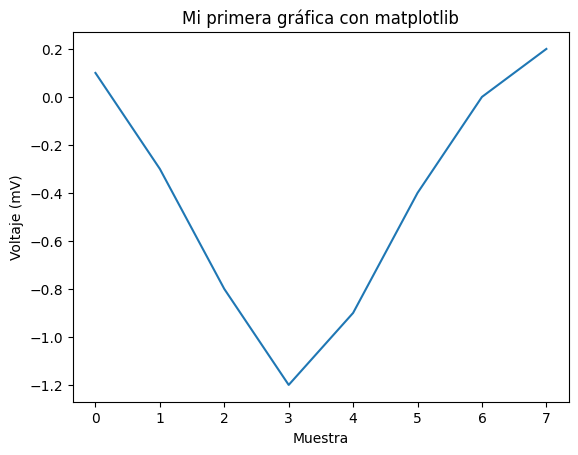

In [43]:
señal = np.array([0.1, -0.3, -0.8, -1.2, -0.9, -0.4, 0.0, 0.2])
 
plt.plot(señal)
plt.title("Mi primera gráfica con matplotlib")
plt.xlabel("Muestra")
plt.ylabel("Voltaje (mV)")
plt.show()

### <span style="color: red;"> Tasas de muestreo </span> 

Antes de seguir, vale la pena detenerse en un concepto que aparecerá constantemente cuando trabajemos con señales: la tasa de muestreo (sampling rate).

Cuando registramos una señal continua del cerebro (como un potencial de campo), la computadora no puede almacenar todos los valores de voltaje en cada instante — son infinitos. Lo que hace es tomar "fotografías" del voltaje a intervalos regulares. La cantidad de fotografías por segundo es la tasa de muestreo. En nuestros datos, la tasa es de 16,000 muestras por segundo (16 kHz), lo que significa que cada 1/16000 = 0.0000625 segundos se captura un valor.

Pero ¿qué pasa si tomamos pocas muestras? Para entenderlo de forma intuitiva, hagamos el siguiente ejercicio:

---
<p>
  <img src="img/cat_dancing.gif"
       width="60"
       height="60"
       style="border-radius: 50%; object-fit: cover; border: 1px solid blue;" />
  <span style="color: blue; font-size: 40px;">Ejercicios</span>
</p>

1. Genera una serie de 25 números de 0 al 20 (pista: `np.linspace()`) y almacénala en una variable `m`
2. Obten la función seno de este vector (pista: `np.sin()`) y almacénala en una variable `seno_de_m`
3. Haz un gráfico de `m` en el eje x y `seno_de_m` en el eje y (pista: `plt.plot`) y muéstralo (pista: `plt.show`)
   
(Los nombres de variable son opcionales, obviamente)

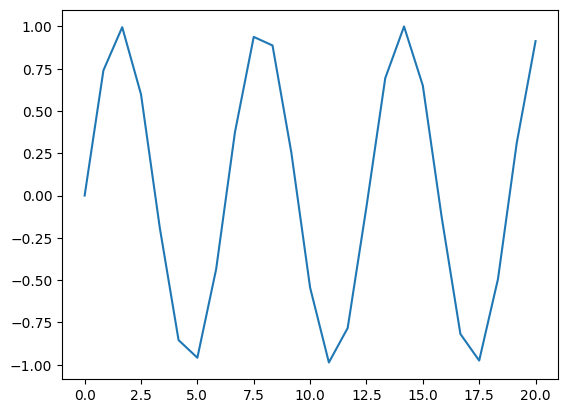

In [44]:
m         = np.linspace(0,20,25)
seno_de_m = np.sin(m)
plt.plot(m, seno_de_m)
plt.show()

5. Ahora genera una serie más densa, de 100 números de 0 al 20 (pista: `np.linspace()`) y almacénala en una variable `m`
6. Genera un gráfico idéntico con este nuevo `m`
7. Comenta ¿Cúal es la diferencia entre el primer y segundo gráfico?

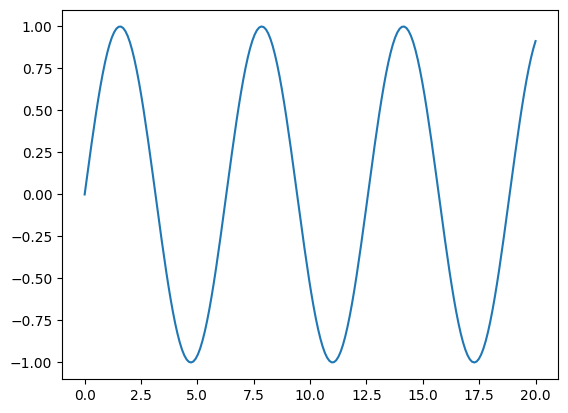

In [45]:
m         = np.linspace(0,20,200)
seno_de_m = np.sin(m)
plt.plot(m, seno_de_m)
plt.show()

---

Con 25 puntos, la curva se ve angulosa — podemos distinguir los segmentos rectos que unen cada punto. Con 100 puntos, la curva se ve suave, mucho más parecida a la función seno real que es continua.
La función seno no cambió en ningún momento. Lo que cambió fue la densidad con la que la muestreamos. Esto es exactamente lo que ocurre con las señales del cerebro:

Una tasa de muestreo baja puede hacer que perdamos detalles rápidos de la señal (como un pico breve del fEPSP).
Una tasa de muestreo alta captura la forma de la señal con mayor fidelidad, pero genera archivos más grandes.

En nuestro caso, los 16 kHz del estudio son suficientes para capturar con precisión los fEPSP, cuyas deflexiones principales ocurren en la escala de milisegundos. Cada milisegundo de señal contiene 16 muestras, lo cual da una resolución más que adecuada para medir pendientes.

### <span style="color: red;"> 3. YAAAAAA, AHORA SI GRAFIQUEMOS UNA TRAZA DE fEPSP  </span>

Si pudiste realizar el último ejercicio de la sección B, podrás apreciar que los datos están muy anidados. Elijamos el ratón número 20, porque sirve como sujeto modelo y sus datos se usan en muchas figuras del artículo. Para tener un adecuado contexto, repetiremos la importación del archivo.

In [46]:
import scipy
datos = scipy.io.matlab.loadmat("data/mousedata.mat",simplify_cells = True)

datos_crudos   = datos['dd']['raw']
datos_shocked  = datos_crudos['shocked']
mouses_shocked = datos_shocked['mouse']

# ratón número 20 es mouses_shocked[19] (lo averigué usando nuestra función esquema()
raton_n_veinte = mouses_shocked[19]

Ahora veamos la estructura de `raton_n_veinte`:

In [47]:
esquema(raton_n_veinte)

└── raíz → dict (4 claves)
    ├── mouse_id → int: 20
    ├── pre → dict (7 claves)
    │   ├── ephys_start_time → str: '2018-07-16_10-17-25'
    │   ├── ephys_start_ts → float: 2457451809.0
    │   ├── ephys_stop_ts → float: 9641234778.0
    │   ├── motion → dict (3 claves)
    │   │   ├── bin_width → int: 5
    │   │   ├── t → np.ndarray shape=(1428,) dtype=float64
    │   │   └── motion_index → np.ndarray shape=(1428,) dtype=float64
    │   ├── inst_speed → dict (2 claves)
    │   │   ├── peri_event_speed → np.ndarray shape=(120, 9) dtype=float64
    │   │   │   ├── [0] → np.ndarray shape=(9,) dtype=float64
    │   │   │   ├── [1] → np.ndarray shape=(9,) dtype=float64
    │   │   │   ├── [2] → np.ndarray shape=(9,) dtype=float64
    │   │   │   ├── [3] → np.ndarray shape=(9,) dtype=float64
    │   │   │   ├── ... (115 filas más)
    │   │   │   └── [119] → np.ndarray shape=(9,) dtype=float64
    │   │   └── event_ts → np.ndarray shape=(120,) dtype=float64
    │   ├── beh_state → dic

Ante esta cantidad abrumadora de datos, simplemente empezemos por el principio, el primer canal, y el primer pulso de la etapa `pre` que sería

In [48]:
primera_traza = raton_n_veinte["pre"]["chan"][0]["stim_pulses"][0]['y']
print(primera_traza)

[-1.15709197e-04 -1.16463644e-04 -1.19349053e-04 -1.20338929e-04
 -1.21474066e-04 -1.13442266e-04 -1.17419771e-04 -1.25000154e-04
 -1.24865041e-04 -1.27650048e-04 -1.18222724e-04 -1.24499243e-04
 -1.26143689e-04 -1.20737636e-04 -1.23158401e-04 -1.22706505e-04
 -1.29490226e-04 -1.13649971e-04 -1.23678273e-04 -1.24300166e-04
 -1.21148188e-04 -1.39219682e-04 -1.13138972e-04 -1.35400551e-04
 -1.19965432e-04 -1.34935383e-04 -1.38575666e-04 -1.03706380e-04
 -1.97397408e-04 -1.05131794e-04 -1.45207231e-04 -7.43868344e-05
 -1.34321280e-04 -1.01298136e-03 -7.13470345e-04  2.11294390e-04
  1.17305424e-05 -7.37660183e-05 -4.86579289e-05 -1.27930357e-04
 -7.78091329e-05 -1.24604255e-04 -9.42209599e-05 -1.09360200e-04
 -1.20539361e-04 -1.05658082e-04 -1.21060348e-04 -8.63313605e-05
 -9.68857923e-05 -9.17201653e-05 -8.43396427e-05 -9.55383346e-05
 -9.08948455e-05 -1.01798190e-04 -1.02393575e-04 -1.09162422e-04
 -1.10301314e-04 -1.06304633e-04 -1.12582637e-04 -1.16517679e-04
 -1.31277646e-04 -1.39362

Este es un arreglo de numpy. El cuál podemos graficar directamente usando lo que ya aprendimos en la sección de matplotlib.

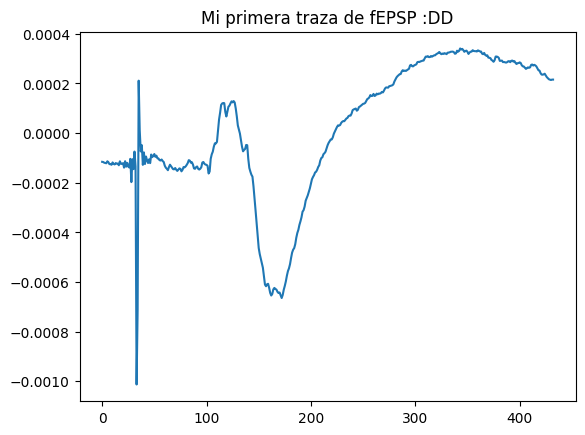

In [49]:
plt.plot(primera_traza)
# Podemos agregar un título con la siguiente orden
plt.title('Mi primera traza de fEPSP :DD')
plt.show()

Sin embargo, hay un detalle importante. Como vimos anteriormente, si no específicamos un eje x en la función `plt.plot(x,y)`, esta genera una serie desde 0 hasta el número de valores en el arreglo. Entonces el eje y muestra solamente el índice de las muestras y esto no es muy informativo.
Generemos, pues, un eje x apropiado sabiendo que la tasa de muestreo es de 16KHz:

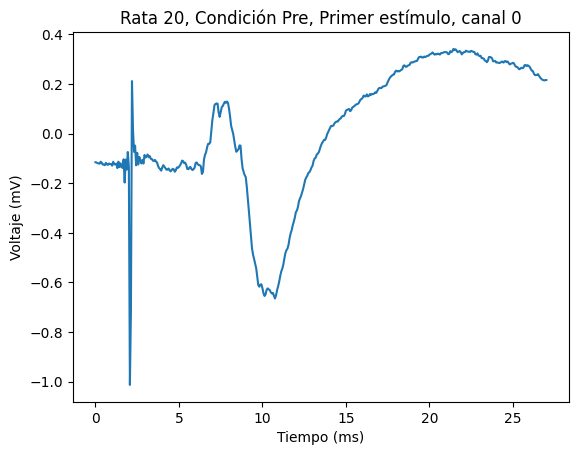

In [50]:
dt            = 1/16000

# tiempo en segundos
eje_de_tiempo = dt*np.arange(len(primera_traza))
# tiempo en milisegundos
eje_de_tiempo = eje_de_tiempo*1000

# podemos hacer de hecho lo mismo con la traza, para mostrarla en mV (está en V)
primera_traza = primera_traza*1000

plt.plot(eje_de_tiempo,primera_traza)

# el título de los ejes se puede colocar de la siguiente manera:
plt.ylabel('Voltaje (mV)')
plt.xlabel('Tiempo (ms)')

# Título:
plt.title('Rata 20, Condición Pre, Primer estímulo, canal 0')

plt.show()

---
<p>
  <img src="img/cat_dancing.gif"
       width="60"
       height="60"
       style="border-radius: 50%; object-fit: cover; border: 1px solid blue;" />
  <span style="color: blue; font-size: 40px;">Ejercicio</span>
</p>

1. Grafica la segunda traza para el ratón 20 (Condición Pre, Segundo estímulo, canal 0). Se te alienta a copiar y pegar código mostrado anteriormente y simplemente modificarlo.

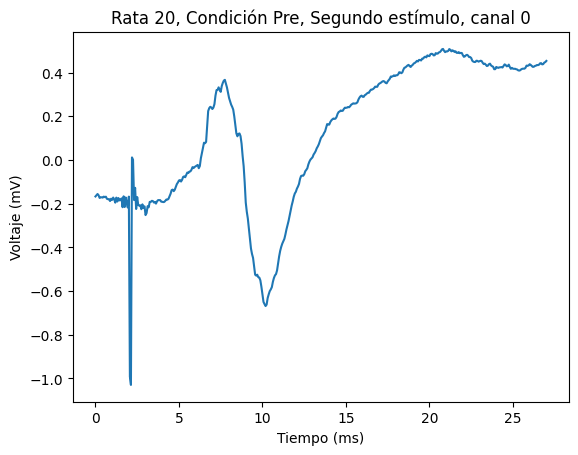

In [51]:
segunda_traza = raton_n_veinte["pre"]["chan"][0]["stim_pulses"][1]['y']
dt            = 1/16000

# tiempo en segundos
eje_de_tiempo = dt*np.arange(len(segunda_traza))
# tiempo en milisegundos
eje_de_tiempo = eje_de_tiempo*1000

# podemos hacer de hecho lo mismo con la traza, para mostrarla en mV (está en V)
segunda_traza = segunda_traza*1000

plt.plot(eje_de_tiempo,segunda_traza)

# el título de los ejes se puede colocar de la siguiente manera:
plt.ylabel('Voltaje (mV)')
plt.xlabel('Tiempo (ms)')

# Título:
plt.title('Rata 20, Condición Pre, Segundo estímulo, canal 0')

plt.show()


---

<center>
  <img src="img/luna-crunchycat1.gif"
       width="60"
       height="60"
       style="border-radius: 50%; object-fit: cover; border: 1px solid blue;" />
  <span style="color: blue; font-size: 30px;">Interludio: Bucles y gráficos con múltiples paneles</span>
      <img src="img/luna-crunchycat1.gif"
       width="60"
       height="60"
       style="border-radius: 50%; object-fit: cover; border: 1px solid blue;" />
</center>

#### <span style="color: blue;"> Bucles `for`</span>

Muchas veces necesitamos realizar una operación con cada elemento de una lista o arreglo: calcular la pendiente de cada pulso, o imprimir el nombre de cada ratón. Para eso usamos el bucle `for`:

In [52]:
ratas = ["Bigotes", "Canela", "Pelusa", "Trueno", "Manchas"]
 
for nombre in ratas:
    print("Hola,", nombre)

Hola, Bigotes
Hola, Canela
Hola, Pelusa
Hola, Trueno
Hola, Manchas


Vemos que en cada vuelta del bucle, la variable `nombre` toma el valor del siguiente elemento de la lista. El bloque de código indentado se ejecuta una vez por cada elemento.

#### <span style="color: blue;"> Gráficos con múltiples paneles </span>
Hasta ahora hemos hecho un solo gráfico por figura. Pero muchas veces necesitamos comparar señales alineadas en el mismo eje de tiempo, como una traza y su derivada. Para eso, Matplotlib nos permite crear múltiples paneles (llamados *axes*) dentro de una misma figura usando `plt.subplots()`.

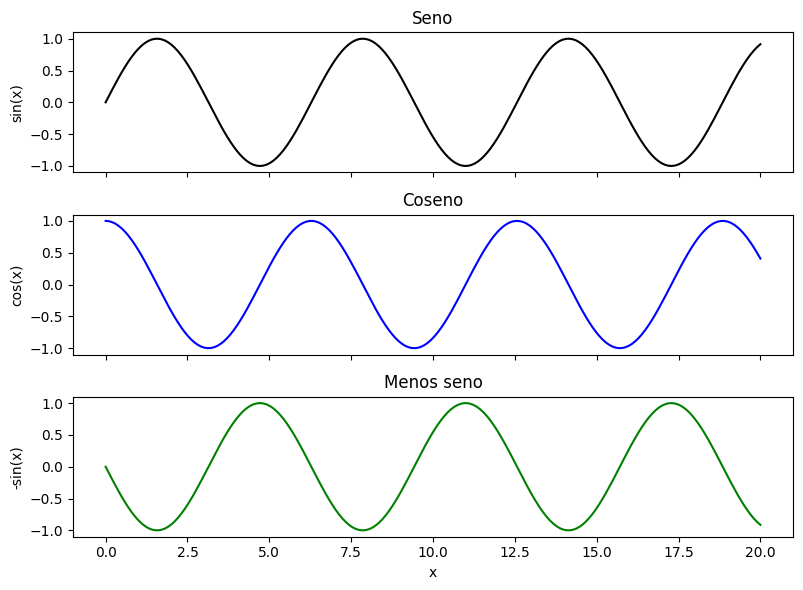

In [53]:
# Crear una figura con 3 paneles apilados
# El argumento figsize es importante para no obtener gráficos aplanados o alargados
# El argumento sharex es para que los gráficos compartan el mismo eje x
fig, axs = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

# Luego en lugar de llamar a `plt.plot()`, llamamos a `axs[i].plot()` para dibujar en un panel específico:
x = np.linspace(0, 20, 200)

# Panel 1, nota que hacemos el cálculo de y en la misma función
axs[0].plot(x, np.sin(x), color="black")
axs[0].set_title("Seno")
axs[0].set_ylabel("sin(x)")

# Panel 2, nota que hacemos el cálculo de y en la misma función
axs[1].plot(x, np.cos(x), color="blue")
axs[1].set_title("Coseno")
axs[1].set_ylabel("cos(x)")

# Panel 3, nota que hacemos el cálculo de y en la misma función
axs[2].plot(x, -np.sin(x), color="green")
axs[2].set_title("Menos seno")
axs[2].set_ylabel("-sin(x)")
axs[2].set_xlabel("x")
 
plt.tight_layout()  # Ajusta el espaciado para que no se sobrepongan
plt.show()

¿Qué hace `plt.subplots()`??: Tenemos ahora dos variables asignadas con lo siguiente:
- `fig`: el objeto que representa la figura completa (el "lienzo").
- `axs`: un arreglo con los paneles individuales. En este caso, `axs[0]` es el panel de arriba, `axs[1]` el del medio, y `axs[2]` el de abajo.
Usaremos esta herramienta constantemente de aquí en adelante para comparar la traza de fEPSP con sus derivadas.

# <span style="color: red;">D. Derivadas y el cálculo de la pendiente del fEPSP</span>

En el artículo de Subramaniyan et al. (2021) la medida principal de fuerza sináptica es la pendiente (slope). En este caso, dado el sitio de registro, este está ubicado en la parte descendente del fEPSP:

<center> <img src="img/Radahmadi-2.png" width=700px /> </center>
<span style="color: blue;"><center><b>Radahmadi et. al. (2025). Figura 2: La forma de las trazas depende del lugar de registro y estimulación </b> </center></span>

Nuestras trazas tienen un inicio, una zona de máxima pendiente, y luego se aplana al llegar al pico negativo. ¿Cómo identificamos  y dónde empieza la zona de interés y dónde termina?: Una herramienta útil para este fin son las derivadas.

#### <span style="color: blue;">Primera derivada </span>
La primera derivada nos muestra dónde sube y dónde baja una función, es decir, nos dice su tasa de cambio en cada punto. En concreto:

- Cuando la derivada es positiva, la función está subiendo.
- Cuando la derivada es negativa, la función está bajando.
- Cuando la derivada es cero, la función tiene un máximo o mínimo local.

Veamos esto con la función seno:

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# Generar la función seno para valores de 0 a 20
x  = np.linspace(0, 20, 500)
y  = np.sin(x)
dx = x[1] - x[0]

# Calcular la primera derivada numéricamente
dy = np.gradient(y, dx)  

Ahora, generamos un gráfico de múltiples paneles para apreciar mejor que podemos apreciar con la derivada.

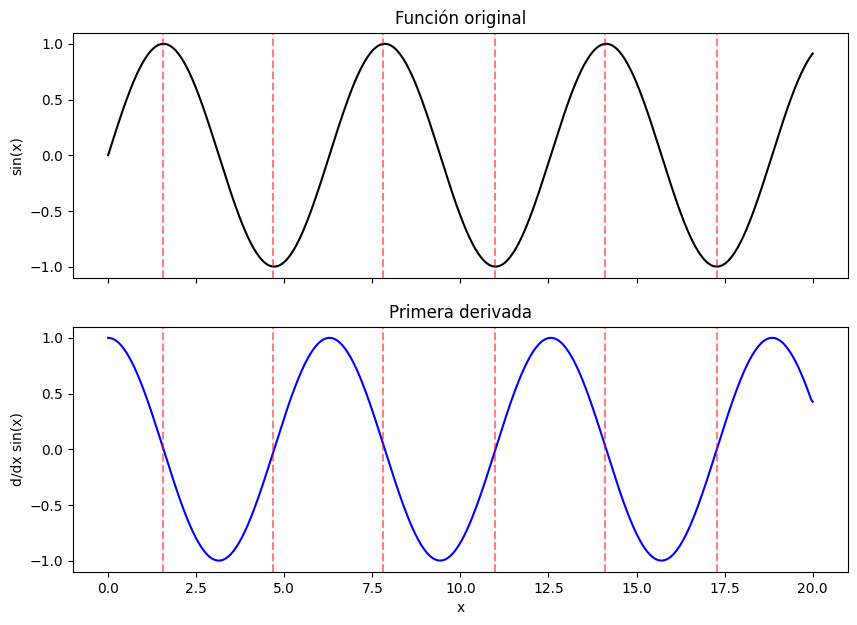

In [55]:
fig, axs = plt.subplots(2, figsize=(10, 7), sharex=True)

# Función original
axs[0].plot(x, y, color="black")
axs[0].set_ylabel("sin(x)")
axs[0].set_title("Función original")

# Primera derivada
axs[1].plot(x, dy, color="blue")
axs[1].set_ylabel("d/dx sin(x)")
axs[1].set_title("Primera derivada")
axs[1].set_xlabel("x")


# Marcar los máximos y mínimos del seno (donde la derivada cruza por cero)
# Buscamos cruces por cero de la derivada
cruces = np.where(np.diff(np.sign(dy)))[0]
for c in cruces:
    axs[0].axvline(x[c], color="red", linestyle="--", alpha=0.5)
    axs[1].axvline(x[c], color="red", linestyle="--", alpha=0.5)


plt.show()

Las líneas verticales rojas marcan los puntos donde la primera derivada cruza por cero. Si miramos hacia arriba, coinciden exactamente con los máximos y mínimos de la función seno.

#### <span style="color: blue;">En la traza de fEPSP</span>


1. Quitaremos el artefacto quitando un número fijo de muestras al final (recordar slicing). Esto es provisional.
2. En el punto de inflexión a mitad del pico negativo, podemos ver el pico de la primera derivada
3. Formaremos una ventana fija de 10 muestras antes y después de este punto.
4. La pendiente la hallaremos entonces con una regresión lineal entre estos dos puntos (`np.polyfit()`)

In [56]:
# Extraer la traza del ratón #20, post-condicionamiento, canal 0, pulso 0
traza = raton_n_veinte["pre"]["chan"][0]["stim_pulses"][1]['y']
dt            = 1/16000
 
# Remover el artefacto de estimulación (primeras 80 muestras ≈ 5 ms)
traza = traza[80:]
 
# Intervalo de muestreo
dt = 1.0 / 16000  # segundos
 
# Primera derivada
first_derivative = np.gradient(traza, dt)

Punto de inflexión: muestra 63
Primer limte 58
Segundo limte 68


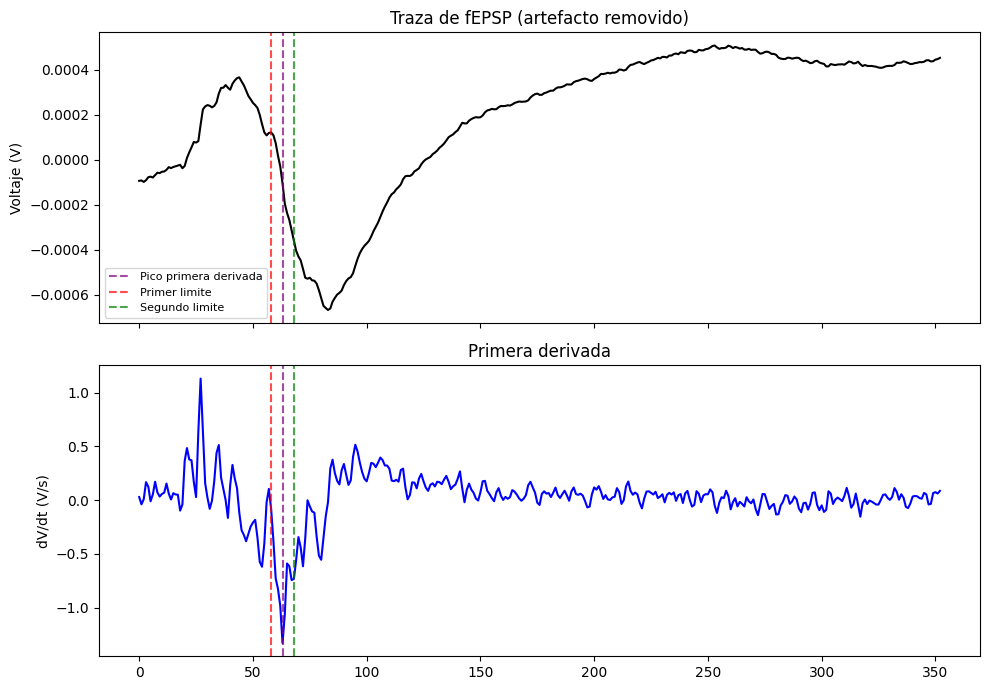

In [57]:
# El mínimo de la primera derivada marca el punto de inflexión
pico_primera_derivada = np.argmin(first_derivative)
 
# Definir ventana de +/- 5ms (+/-80 muestras)
primer_limite = pico_primera_derivada - 5
segundo_limite = pico_primera_derivada + 5
 
print(f"Punto de inflexión: muestra {pico_primera_derivada}")
print(f"Primer limte {primer_limite}")
print(f"Segundo limte {segundo_limite}")

 
### Paso 3: Visualizar la traza y sus derivada
 

fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
 
muestras = np.arange(traza.shape[0])
 
# Traza cruda
axs[0].plot(muestras, traza, color="black")
axs[0].set_title("Traza de fEPSP (artefacto removido)")
axs[0].set_ylabel("Voltaje (V)")
 
# Primera derivada
axs[1].plot(muestras, first_derivative, color="blue")
axs[1].set_title("Primera derivada")
axs[1].set_ylabel("dV/dt (V/s)")
 
# Marcar el punto de inflexión y los límites en los tres paneles
for ax in axs:
    ax.axvline(pico_primera_derivada, color="purple", linestyle="--",
               alpha=0.7, label="Pico primera derivada")
    ax.axvline(primer_limite, color="red", linestyle="--",
               alpha=0.7, label="Primer limite")
    ax.axvline(segundo_limite , color="green", linestyle="--",
               alpha=0.7, label="Segundo limite")
 
axs[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

#### <span style="color: blue;">Calcular la pendiente (regresión lineal)</span>
Para obtener la pendiente, ajustamos una recta a los datos entre el primer límite y el segundo límite usando `np.polyfit()`, que ajusta un polinomio de grado 1 (una recta) a los datos:

In [58]:
x_fit = np.arange(primer_limite, segundo_limite)
y_fit = traza[primer_limite:segundo_limite]
 
# Ajustar una línea recta (polinomio de grado 1)
slope, intercept = np.polyfit(x_fit, y_fit, 1)
fit_line = slope * x_fit + intercept
 
print(f"Pendiente (slope): {slope:.6f} V/muestra")
print(f"Pendiente en V/s: {slope * 16000:.4f} V/s")

Pendiente (slope): -0.000054 V/muestra
Pendiente en V/s: -0.8565 V/s


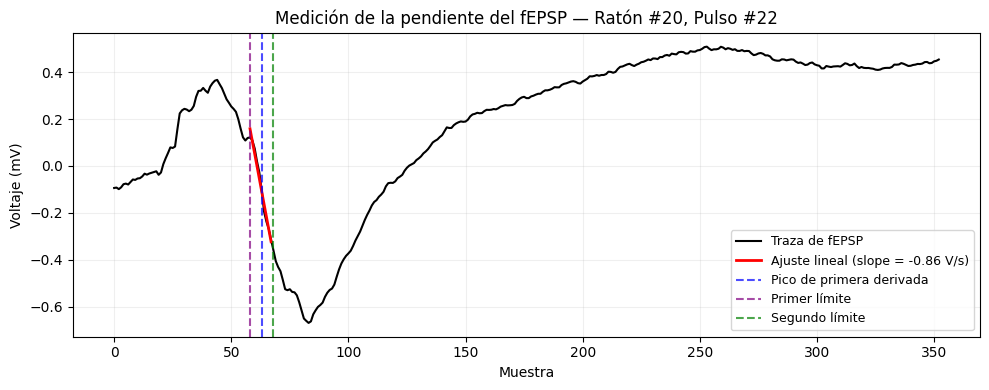

In [59]:
plt.figure(figsize=(10, 4))
plt.plot(traza * 1000, color="black", label="Traza de fEPSP")
plt.plot(x_fit, fit_line * 1000, color="red", linewidth=2,
         label=f"Ajuste lineal (slope = {slope * 16000:.2f} V/s)")
plt.axvline(pico_primera_derivada, color="blue", linestyle="--", alpha=0.7,
            label="Pico de primera derivada")
plt.axvline(primer_limite, color="purple", linestyle="--", alpha=0.7,
            label="Primer límite")
plt.axvline(segundo_limite, color="green", linestyle="--", alpha=0.7,
            label="Segundo límite")
plt.xlabel("Muestra")
plt.ylabel("Voltaje (mV)")
plt.title("Medición de la pendiente del fEPSP — Ratón #20, Pulso #22")
plt.legend(fontsize=9)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

---
<p>
  <img src="img/cat_dancing.gif"
       width="60"
       height="60"
       style="border-radius: 50%; object-fit: cover; border: 1px solid blue;" />
  <span style="color: blue; font-size: 40px;">Ejercicio</span>
</p>

1. Ejecuta la siguiente celda, y luego de manipular el control que aparecerá abajo, observa el efecto de ampliar o disminuir la ventana en la pendiente.

In [60]:
from ipywidgets import interact

interact(lambda ventana: visualizar(traza, ventana),
         ventana=(1, 20, 1))
raton_n_veinte["pre"]["chan"][0]["stim_pulses"][1]['fepsp_slope']

interactive(children=(IntSlider(value=10, description='ventana', max=20, min=1), Output()), _dom_classes=('wid…

-0.8824293873120842

# <span style="color: red;">E. Generalizando..</span>

Ya sabemos calcular la pendiente de una sola traza. Ahora necesitamos hacer lo mismo para cada pulso de estimulación, de cada canal, de cada ratón, en las condiciones pre y post. Es aquí donde los bucles `for` y las funciones se vuelven indispensables.

#### <span style="color: blue;">Funciones</span>


Una función es un bloque de código reutilizable que realiza una tarea específica. Permite organizar el programa, evitar repeticiones y hacer el código más claro. Podemos apreciar sus componentes en la siguiente figura:

<center> <img src="img/esquema-funciones-python.png" width = 700> </center>
<span style="color: blue;"><center><b>Imágen de https://j2logo.com/python/tutorial/funciones-en-python/</center></b></span>

Definamos entonces una función con el código que ya escribimos arriba:

In [61]:
def calcular_slope(pulso, umbral_us=2000, fs=16000, ventana=6):
        traza = pulso['y']
        rel_t = pulso['rel_t']
        
        # Recortar: quedarnos solo con las muestras después del umbral
        mascara = rel_t >= umbral_us
        traza = traza[mascara]
        
        # Verificar que queden suficientes muestras
        if len(traza) < 2 * ventana + 1:
            return np.nan
        
        # Intervalo de muestreo
        dt = 1.0 / fs
        
        # Primera derivada
        first_derivative  = np.gradient(traza, dt)
        
        # Punto de inflexión (mínimo de la segunda derivada)
        pico_first_derivative = np.argmin(first_derivative)
        
        # Definir ventana alrededor del punto de inflexión
        primer_limite  = pico_first_derivative- ventana
        segundo_limite = pico_first_derivative + ventana

        
        # Verificar que los límites estén dentro de la traza
        if primer_limite < 0 or segundo_limite >= len(traza):
            return np.nan
        
        # Ajuste lineal
        x_fit = np.arange(primer_limite, segundo_limite)
        y_fit = traza[primer_limite:segundo_limite]
        slope, intercept = np.polyfit(x_fit, y_fit, 1)
        
        # Convertir de V/muestra a V/s
        slope_Vs = slope * fs
        
        return slope_Vs

Probemos que funciona con una traza:

In [62]:
pulso_prueba = raton_n_veinte["pre"]["chan"][0]["stim_pulses"][0]
resultado = calcular_slope(pulso_prueba)
print(f"Slope: {resultado:.4f} V/s")

Slope: -0.6182 V/s


Como funciona podemos continuar extrapolando a todos los pulsos de un ratón:

In [63]:
resultados = {
    "mouse_id":  [],
    "condicion": [],
    "canal":     [],
    "pulso":     [],
    "slope_Vs":  [],
    "slope_autores": []
}
 
ratones = datos['dd']['raw']['shocked']['mouse']
 
for idx_raton in range(len(ratones)):
    raton = ratones[idx_raton]
    mouse_id = raton['mouse_id']
    
    for condicion in ["pre", "post"]:
        session = raton[condicion]
        
        canales = session["chan"]
        if isinstance(canales, dict):
            canales = [canales]
        
        for idx_canal in range(len(canales)):
            canal = canales[idx_canal]
            pulsos = canal["stim_pulses"]
            
            if isinstance(pulsos, dict):
                pulsos = [pulsos]
            
            for idx_pulso in range(len(pulsos)):
                pulso = pulsos[idx_pulso]
                slope = calcular_slope(pulso)
                
                resultados["mouse_id"].append(mouse_id)
                resultados["condicion"].append(condicion)
                resultados["canal"].append(idx_canal)
                resultados["pulso"].append(idx_pulso)
                resultados["slope_Vs"].append(slope)
                resultados["slope_autores"].append(pulso['fepsp_slope'])
 
# Convertir a arrays de numpy
for clave in resultados:
    resultados[clave] = np.array(resultados[clave])
 
print(f"Total de pendientes calculadas: {len(resultados['slope_Vs'])}")
print(f"Pendientes válidas: {np.sum(~np.isnan(resultados['slope_Vs']))}")
print(f"Pendientes fallidas (NaN): {np.sum(np.isnan(resultados['slope_Vs']))}")

Total de pendientes calculadas: 18448
Pendientes válidas: 18433
Pendientes fallidas (NaN): 15


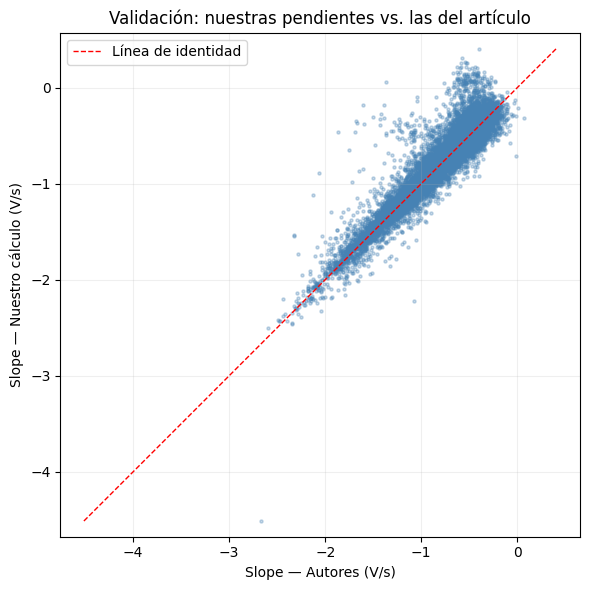

In [64]:
# Filtrar solo las pendientes válidas (sin NaN)
validos = ~np.isnan(resultados["slope_Vs"])
nuestros = resultados["slope_Vs"][validos]
autores  = resultados["slope_autores"][validos]
 
plt.figure(figsize=(6, 6))
plt.scatter(autores, nuestros, s=5, alpha=0.3, color="steelblue")
 
# Línea de identidad (si fueran iguales, todos los puntos caerían aquí)
limites = [min(autores.min(), nuestros.min()), max(autores.max(), nuestros.max())]
plt.plot(limites, limites, 'r--', linewidth=1, label="Línea de identidad")
 
plt.xlabel("Slope — Autores (V/s)")
plt.ylabel("Slope — Nuestro cálculo (V/s)")
plt.title("Validación: nuestras pendientes vs. las del artículo")
plt.legend()
plt.grid(True, alpha=0.2)
plt.axis("equal")
plt.tight_layout()
plt.show()
 

In [65]:
# Correlación
correlacion = np.corrcoef(autores, nuestros)[0, 1]
print(f"Correlación entre nuestros slopes y los de los autores: {correlacion:.5f}")


Correlación entre nuestros slopes y los de los autores: 0.94053


# <span style="color: red;">E. Replicando gráficos</span>

## <span style="color: red;">Gráfico 2B</span>

Ahora que tenemos las pendientes de todas las trazas, vamos a replicar uno de los gráficos principales del artículo: el heatmap de la Figura 2b. En este gráfico, cada fila es un electrodo, cada columna es un bin de 5 minutos, y el color representa la pendiente del fEPSP normalizada a la línea base (100% = sin cambio, rojo = potenciación, azul = depresión).

<center> <img src="img/grafico_2b.png" width=600px /> </center>
<span style="color: blue;"><center><b>Subramaniyan et. al (2021)</b> </center></span>


Para cada electrodo (combinación de ratón + canal), necesitamos dividir todas las pendientes por el promedio de la línea base (pre) y multiplicar por 100:

In [66]:
# Obtener todas las combinaciones únicas de ratón + canal
ratones_unicos = np.unique(resultados["mouse_id"])
 
# Lista para almacenar los datos de cada electrodo (cada fila del heatmap)
filas_heatmap = []
etiquetas_raton = []  # Para saber a qué ratón pertenece cada fila
 
for mouse_id in ratones_unicos:
    mascara_raton = resultados["mouse_id"] == mouse_id
    canales_del_raton = np.unique(resultados["canal"][mascara_raton])
    
    for canal in canales_del_raton:
        # Filtrar pendientes de este electrodo específico
        mascara_pre = (mascara_raton & 
                       (resultados["condicion"] == "pre") & 
                       (resultados["canal"] == canal))
        mascara_post = (mascara_raton & 
                        (resultados["condicion"] == "post") & 
                        (resultados["canal"] == canal))
        
        slopes_pre  = resultados["slope_Vs"][mascara_pre]
        slopes_post = resultados["slope_Vs"][mascara_post]
        
        # Promedio de la línea base (ignorando NaN)
        baseline_mean = np.nanmean(slopes_pre)
        
        # Evitar división por cero
        if baseline_mean == 0 or np.isnan(baseline_mean):
            continue
        
        # Normalizar: (slope / baseline) * 100
        slopes_pre_norm  = (slopes_pre / baseline_mean) * 100
        slopes_post_norm = (slopes_post / baseline_mean) * 100
        
        filas_heatmap.append({
            "mouse_id": mouse_id,
            "canal": canal,
            "pre": slopes_pre_norm,
            "post": slopes_post_norm
        })
        etiquetas_raton.append(mouse_id)
 
print(f"Número de electrodos (filas del heatmap): {len(filas_heatmap)}")

Número de electrodos (filas del heatmap): 62


#### <span style="color: blue;"> Agrupar en bines de 5 minutos</span>
 
Cada pulso de estimulación ocurre cada 60 segundos, así que un bin de 5 minutos contiene ~5 pulsos. Para la línea base (2 h = 120 min) tenemos ~24 bins, y para post (3 h = 180 min) tenemos ~36 bins:

In [67]:
def binnear(slopes, bin_size=5):
    """
    Agrupa un array de pendientes en bins de `bin_size` elementos
    y calcula el promedio de cada bin (ignorando NaN).
    """
    n = len(slopes)
    n_bins = int(np.ceil(n / bin_size))
    binned = np.full(n_bins, np.nan)
    
    for i in range(n_bins):
        inicio = i * bin_size
        fin = min(inicio + bin_size, n)
        segmento = slopes[inicio:fin]
        if len(segmento) > 0:
            binned[i] = np.nanmean(segmento)
    
    return binned

#### <span style="color: blue;"> Extraer datos </span>

In [68]:
# Número máximo de bins para pre y post
# Pre: 120 pulsos / 5 = 24 bins (2 horas)
# Post: 180 pulsos / 5 = 36 bins (3 horas)
n_bins_pre = 24
n_bins_post = 36
n_bins_total = n_bins_pre + n_bins_post
 
# Construir la matriz del heatmap
heatmap_matrix = np.full((len(filas_heatmap), n_bins_total), np.nan)
 
for i, fila in enumerate(filas_heatmap):
    pre_binned  = binnear(fila["pre"], bin_size=5)
    post_binned = binnear(fila["post"], bin_size=5)
    
    # Colocar los bins de pre (alineados a la derecha para que terminen en t=0)
    n_pre = len(pre_binned)
    inicio_pre = n_bins_pre - n_pre  # Algunos ratones tienen menos baseline
    heatmap_matrix[i, inicio_pre:n_bins_pre] = pre_binned
    
    # Colocar los bins de post (empiezan desde t=0)
    n_post = min(len(post_binned), n_bins_post)
    heatmap_matrix[i, n_bins_pre:n_bins_pre + n_post] = post_binned
 
print(f"Matriz del heatmap: {heatmap_matrix.shape} (electrodos × bins)")

Matriz del heatmap: (62, 60) (electrodos × bins)


#### <span style="color: blue;">Crear el eje de tiempo</span>

In [69]:
# Cada bin = 5 minutos. Pre va de -120 a 0 min, Post de 0 a 180 min.
# Convertimos a horas:
tiempo_bins = np.linspace(-2, 3, n_bins_total, endpoint=False)
 
# El centro de cada bin (desplazar medio bin)
bin_width_h = 5 / 60  # 5 min en horas
tiempo_bins = tiempo_bins + bin_width_h / 2

#### <span style="color: blue;"> Graficar el heatmap </span>

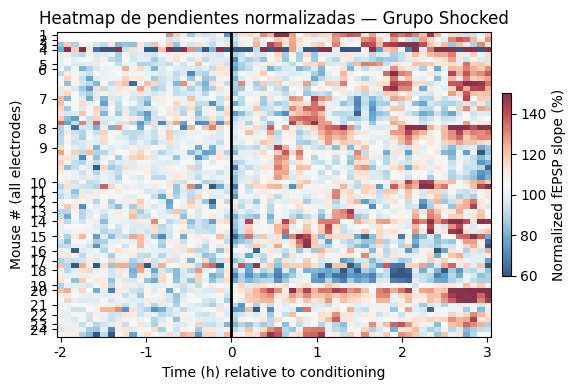

In [70]:
fig, ax = plt.subplots(figsize=(6, 4))
 
# Usar imshow con un colormap divergente centrado en 100
im = ax.imshow(heatmap_matrix, 
               aspect='auto',
               cmap='RdBu_r',  # Rojo = potenciación, Azul = depresión
               vmin=60, 
               vmax=150,
               interpolation='nearest',
              alpha=0.8)
 
# Eje x: tiempo en horas
n_cols = heatmap_matrix.shape[1]
tick_positions_x = np.linspace(0, n_cols - 1, 6)
tick_labels_x = [f"{t:.0f}" for t in np.linspace(-2, 3, 6)]
ax.set_xticks(tick_positions_x)
ax.set_xticklabels(tick_labels_x)
ax.set_xlabel("Time (h) relative to conditioning")
 
# Eje y: marcar los ratones
# Encontrar las posiciones donde cambia el ratón
etiquetas_raton = np.array(etiquetas_raton)
tick_positions_y = []
tick_labels_y = []
prev_id = None
for i, mid in enumerate(etiquetas_raton):
    if mid != prev_id:
        tick_positions_y.append(i)
        tick_labels_y.append(str(int(mid)))
        prev_id = mid
 
ax.set_yticks(tick_positions_y)
ax.set_yticklabels(tick_labels_y)
ax.set_ylabel("Mouse # (all electrodes)")
 
# Línea vertical en t=0 (momento del condicionamiento)
x_cero = n_bins_pre - 0.5  # Borde entre pre y post
ax.axvline(x_cero, color="black", linewidth=2)
 
# Barra de color
cbar = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("Normalized fEPSP slope (%)")
 
ax.set_title("Heatmap de pendientes normalizadas — Grupo Shocked")
plt.tight_layout()
plt.show()

## <span style="color: red;">Gráfico 2C</span>

Este gráfico muestra los datos crudos (puntos plomos) y el promedio en bines de 5 minutos (puntos negros) para el electrodo más potenciado del ratón #20.

<center> <img src="img/figura_2c.png" width=600px /> </center>
<span style="color: blue;"><center><b>Subramaniyan et. al (2021)</b> </center></span>


#### <span style="color: blue;">Extraer y normalizar los datos del ratón #20</span>


In [71]:
# Filtrar datos del ratón #20, canal 0 (el más potenciado según la figura)
mascara_pre = ((resultados["mouse_id"] == 20) & 
               (resultados["condicion"] == "pre") & 
               (resultados["canal"] == 0))
mascara_post = ((resultados["mouse_id"] == 20) & 
                (resultados["condicion"] == "post") & 
                (resultados["canal"] == 0))

slopes_pre  = resultados["slope_Vs"][mascara_pre]
slopes_post = resultados["slope_Vs"][mascara_post]

# Normalizar al promedio de la línea base
baseline_mean = np.nanmean(slopes_pre)
slopes_pre_norm  = (slopes_pre / baseline_mean) * 100
slopes_post_norm = (slopes_post / baseline_mean) * 100

print(f"Pulsos pre: {len(slopes_pre_norm)}, Pulsos post: {len(slopes_post_norm)}")
print(f"Promedio baseline: {baseline_mean:.4f} V/s")

Pulsos pre: 120, Pulsos post: 180
Promedio baseline: -0.5458 V/s


#### <span style="color: blue;">Crear el eje de tiempo en horas</span>

Cada pulso ocurre cada 60 segundos. La línea base dura 2 horas (tiempos negativos) y el post-condicionamiento dura 3 horas (tiempos positivos):

In [72]:
# Pre: de -2h a 0h
tiempo_pre = np.linspace(-2, 0, len(slopes_pre_norm), endpoint=False)

# Post: de 0h a 3h
tiempo_post = np.linspace(0, 3, len(slopes_post_norm), endpoint=False)

#### <span style="color: blue;">Calcular los promedios de 5 minutos (bins)</span>

In [73]:
def binnear_con_tiempo(tiempo, slopes, bin_size=5):
    """
    Agrupa slopes en bins de `bin_size` elementos.
    Retorna el tiempo central y el promedio de cada bin.
    """
    n = len(slopes)
    n_bins = int(np.ceil(n / bin_size))
    tiempo_bin = np.full(n_bins, np.nan)
    slopes_bin = np.full(n_bins, np.nan)
    
    for i in range(n_bins):
        inicio = i * bin_size
        fin = min(inicio + bin_size, n)
        tiempo_bin[i] = np.nanmean(tiempo[inicio:fin])
        slopes_bin[i] = np.nanmean(slopes[inicio:fin])
    
    return tiempo_bin, slopes_bin

tiempo_pre_bin, slopes_pre_bin   = binnear_con_tiempo(tiempo_pre, slopes_pre_norm)
tiempo_post_bin, slopes_post_bin = binnear_con_tiempo(tiempo_post, slopes_post_norm)

### <span style="color: blue;"> Graficar</span>

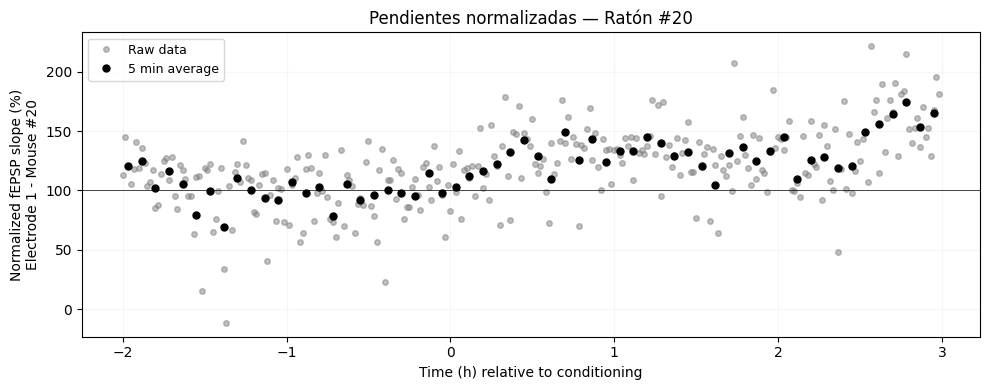

In [74]:
plt.figure(figsize=(10, 4))

# Datos crudos (puntos grises)
plt.plot(tiempo_pre, slopes_pre_norm, 'o', 
         color='gray', markersize=4, alpha=0.5, label='Raw data')
plt.plot(tiempo_post, slopes_post_norm, 'o', 
         color='gray', markersize=4, alpha=0.5)

# Promedios de 5 min (puntos negros)
plt.plot(tiempo_pre_bin, slopes_pre_bin, 'o', 
         color='black', markersize=5, label='5 min average')
plt.plot(tiempo_post_bin, slopes_post_bin, 'o', 
         color='black', markersize=5)

# Línea de referencia en 100%
plt.axhline(100, color='black', linewidth=0.5)

# Etiquetas y formato
plt.xlabel("Time (h) relative to conditioning")
plt.ylabel("Normalized fEPSP slope (%)\nElectrode 1 - Mouse #20")
plt.title("Pendientes normalizadas — Ratón #20")
plt.legend(fontsize=9)
plt.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

# <span style="color: red;">F. Modelos lineares mixtos</span>

Para cerrar, vamos a replicar la Figura 2f del artículo: el promedio a través de todos los ratones de las pendientes normalizadas, con barras de error (SEM), y una prueba estadística para determinar si el post-condicionamiento fue significativamente diferente de la línea base.

<center> <img src="img/2f.png" width=600px /> </center>
<span style="color: blue;"><center><b>Subramaniyan et. al (2021)</b> </center></span>

### <span style="color: blue;"> Seleccionar el electrodo más potenciado de cada ratón</span>

El artículo usa solo un electrodo por ratón: el que mostró mayor potenciación. Para cada ratón, seleccionamos el canal cuyo promedio post-condicionamiento normalizado es el más alto:

In [75]:
ratones_unicos = np.unique(resultados["mouse_id"])

# Guardaremos los datos del electrodo más potenciado de cada ratón
mejor_electrodo = {}

for mouse_id in ratones_unicos:
    mascara_raton = resultados["mouse_id"] == mouse_id
    canales_del_raton = np.unique(resultados["canal"][mascara_raton])
    
    mejor_canal = None
    mejor_potenciacion = -np.inf
    
    for canal in canales_del_raton:
        mascara_pre = (mascara_raton & 
                       (resultados["condicion"] == "pre") & 
                       (resultados["canal"] == canal))
        mascara_post = (mascara_raton & 
                        (resultados["condicion"] == "post") & 
                        (resultados["canal"] == canal))
        
        slopes_pre  = resultados["slope_Vs"][mascara_pre]
        slopes_post = resultados["slope_Vs"][mascara_post]
        
        baseline_mean = np.nanmean(slopes_pre)
        if baseline_mean == 0 or np.isnan(baseline_mean):
            continue
        
        # Potenciación = promedio post normalizado
        potenciacion = np.nanmean(slopes_post) / baseline_mean * 100
        
        if potenciacion > mejor_potenciacion:
            mejor_potenciacion = potenciacion
            mejor_canal = canal
    
    if mejor_canal is not None:
        mascara_pre = (mascara_raton & 
                       (resultados["condicion"] == "pre") & 
                       (resultados["canal"] == mejor_canal))
        mascara_post = (mascara_raton & 
                        (resultados["condicion"] == "post") & 
                        (resultados["canal"] == mejor_canal))
        
        slopes_pre  = resultados["slope_Vs"][mascara_pre]
        slopes_post = resultados["slope_Vs"][mascara_post]
        baseline_mean = np.nanmean(slopes_pre)
        
        mejor_electrodo[mouse_id] = {
            "canal": mejor_canal,
            "pre_norm":  (slopes_pre / baseline_mean) * 100,
            "post_norm": (slopes_post / baseline_mean) * 100
        }

print(f"Ratones con electrodo seleccionado: {len(mejor_electrodo)}")

Ratones con electrodo seleccionado: 24


### <span style="color: blue;"> Binnear a 5 minutos y construir una matriz general </span>

In [76]:
n_bins_pre = 24   # 120 min / 5 min
n_bins_post = 36  # 180 min / 5 min
n_bins_total = n_bins_pre + n_bins_post

# Matriz: ratones × bins
n_ratones = len(mejor_electrodo)
matriz_poblacion = np.full((n_ratones, n_bins_total), np.nan)

for i, (mouse_id, datos_elec) in enumerate(mejor_electrodo.items()):
    pre_binned  = binnear(datos_elec["pre_norm"], bin_size=5)
    post_binned = binnear(datos_elec["post_norm"], bin_size=5)
    
    # Alinear pre a la derecha (termina en t=0)
    n_pre = len(pre_binned)
    inicio_pre = n_bins_pre - n_pre
    matriz_poblacion[i, inicio_pre:n_bins_pre] = pre_binned
    
    # Post empieza en t=0
    n_post = min(len(post_binned), n_bins_post)
    matriz_poblacion[i, n_bins_pre:n_bins_pre + n_post] = post_binned

print(f"Matriz población: {matriz_poblacion.shape} (ratones × bins)")

Matriz población: (24, 60) (ratones × bins)


### <span style="color: blue;"> Calcular promedio y SEM a través de ratones</span>

In [77]:
# Promedio a través de ratones (eje 0), ignorando NaN
promedio = np.nanmean(matriz_poblacion, axis=0)

# SEM = desviación estándar / raíz cuadrada del número de ratones válidos
n_validos = np.sum(~np.isnan(matriz_poblacion), axis=0)  # Ratones válidos por bin
sem = np.nanstd(matriz_poblacion, axis=0) / np.sqrt(n_validos)

# Eje de tiempo en horas
bin_duracion_h = 5 / 60  # 5 min en horas
tiempo = np.arange(n_bins_total) * bin_duracion_h - 2  # Empieza en -2h
tiempo = tiempo + bin_duracion_h / 2  # Centro del bin

 ### <span style="color: blue;"> Graficar la Figura 2f</span>

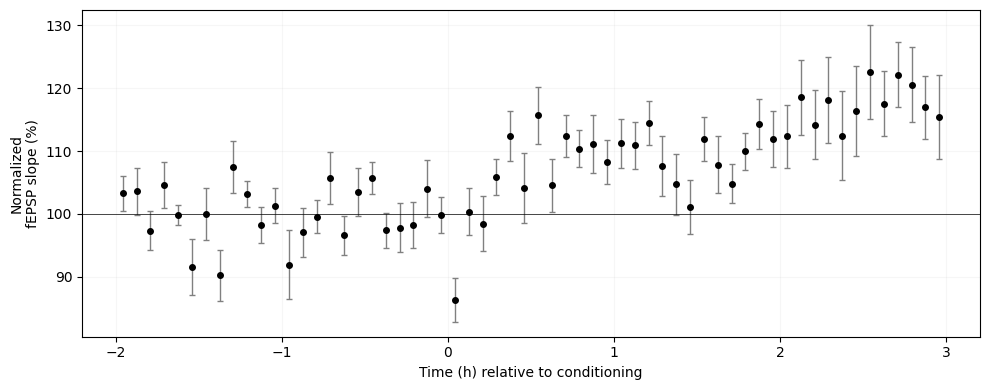

In [78]:
plt.figure(figsize=(10, 4))

# Promedio con barras de error (SEM)
plt.errorbar(tiempo, promedio, yerr=sem, 
             fmt='o', markersize=4, color='black', 
             ecolor='gray', elinewidth=1, capsize=2)

# Línea de referencia en 100%
plt.axhline(100, color='black', linewidth=0.5)

# Etiquetas
plt.xlabel("Time (h) relative to conditioning")
plt.ylabel("Normalized\nfEPSP slope (%)")
plt.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

 ### <span style="color: blue;"> LMM </span>

Los autores trataron la secuencia de pendientes como una serie de tiempo interrumpida (interrupted time series), donde el condicionamiento de miedo "interrumpe" la secuencia de la línea base. Usaron un modelo lineal mixto que permite efectos fijos y efectos aleatorios.

In [79]:
import statsmodels.formula.api as smf

 ### <span style="color: blue;"> Preparar los datos para el LMM </span>

Necesitamos organizar los datos en formato "largo" — una fila por cada medición individual:

In [80]:
# Construir las listas para el modelo
lmm_mouse_id = []
lmm_slope = []
lmm_periodo = []      # 0 = pre, 1 = post
lmm_tiempo = []       # Tiempo en minutos dentro de cada periodo

for mouse_id, datos_elec in mejor_electrodo.items():
    # Pre: tiempo de 0 a 120 min (dentro del periodo pre)
    pre = datos_elec["pre_norm"]
    for j in range(len(pre)):
        if not np.isnan(pre[j]):
            lmm_mouse_id.append(mouse_id)
            lmm_slope.append(pre[j])
            lmm_periodo.append(0)
            lmm_tiempo.append(j)  # Pulso número j (≈ minuto j)
    
    # Post: tiempo de 0 a 180 min (dentro del periodo post)
    post = datos_elec["post_norm"]
    for j in range(len(post)):
        if not np.isnan(post[j]):
            lmm_mouse_id.append(mouse_id)
            lmm_slope.append(post[j])
            lmm_periodo.append(1)
            lmm_tiempo.append(j)

# Convertir a arrays
lmm_mouse_id = np.array(lmm_mouse_id)
lmm_slope = np.array(lmm_slope)
lmm_periodo = np.array(lmm_periodo)
lmm_tiempo = np.array(lmm_tiempo)

print(f"Observaciones totales: {len(lmm_slope)}")
print(f"  Pre:  {np.sum(lmm_periodo == 0)}")
print(f"  Post: {np.sum(lmm_periodo == 1)}")

Observaciones totales: 7039
  Pre:  2725
  Post: 4314


 ### <span style="color: blue;"> Organizar en un diccionario compatible con statsmodels </span>

In [81]:
datos_lmm = {
    "slope": lmm_slope,
    "periodo": lmm_periodo,
    "tiempo": lmm_tiempo,
    "mouse_id": lmm_mouse_id
}

 ### <span style="color: blue;">¿Fue la línea base estable?</span>

In [82]:
# Filtrar solo datos pre
mascara_pre_lmm = lmm_periodo == 0
datos_pre = {
    "slope": lmm_slope[mascara_pre_lmm],
    "tiempo": lmm_tiempo[mascara_pre_lmm],
    "mouse_id": lmm_mouse_id[mascara_pre_lmm]
}

# LMM: ¿el tiempo predice la pendiente durante el baseline?
# Efecto fijo: tiempo
# Efecto aleatorio: intercepto por ratón
import pandas as pd  # statsmodels requiere un DataFrame
df_pre = pd.DataFrame(datos_pre)

modelo_baseline = smf.mixedlm("slope ~ tiempo", 
                               data=df_pre, 
                               groups=df_pre["mouse_id"])
resultado_baseline = modelo_baseline.fit()

print("=" * 60)
print("ANÁLISIS 1: Estabilidad de la línea base")
print("=" * 60)
print(f"Efecto del tiempo en baseline:")
print(f"  Coeficiente: {resultado_baseline.fe_params['tiempo']:.4f}")
print(f"  p-value:     {resultado_baseline.pvalues['tiempo']:.4f}")
if resultado_baseline.pvalues['tiempo'] > 0.05:
    print("  → La línea base ES estable (no hay cambio significativo con el tiempo)")
else:
    print("  → La línea base NO es estable")

ANÁLISIS 1: Estabilidad de la línea base
Efecto del tiempo en baseline:
  Coeficiente: 0.0060
  p-value:     0.7680
  → La línea base ES estable (no hay cambio significativo con el tiempo)


/home/usuario/tns2026-venv/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/usuario/tns2026-venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/usuario/tns2026-venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/home/usuario/tns2026-venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/home/usuario/tns2026-venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.war

 ### <span style="color: blue;"> ¿Hubo potenciación después del condicionamiento? </span>

In [83]:
# Usar todos los datos (pre + post)
df_todo = pd.DataFrame(datos_lmm)

# LMM: ¿el periodo (pre vs post) predice la pendiente?
# Efecto fijo: periodo (0=pre, 1=post) + tiempo dentro de cada periodo
# Efecto aleatorio: intercepto por ratón
modelo_potenciacion = smf.mixedlm("slope ~ periodo + tiempo", 
                                   data=df_todo, 
                                   groups=df_todo["mouse_id"])
resultado_potenciacion = modelo_potenciacion.fit()

print("=" * 60)
print("ANÁLISIS 2: ¿Hubo potenciación post-condicionamiento?")
print("=" * 60)
print(f"Efecto del periodo (pre vs post):")
print(f"  Coeficiente: {resultado_potenciacion.fe_params['periodo']:.4f}")
print(f"  p-value:     {resultado_potenciacion.pvalues['periodo']:.4f}")
if resultado_potenciacion.pvalues['periodo'] < 0.01:
    print("  → Potenciación SIGNIFICATIVA (p < 0.01) **")
elif resultado_potenciacion.pvalues['periodo'] < 0.05:
    print("  → Potenciación SIGNIFICATIVA (p < 0.05) *")
else:
    print("  → No significativo")

print(f"\nEfecto del tiempo:")
print(f"  Coeficiente: {resultado_potenciacion.fe_params['tiempo']:.4f}")
print(f"  p-value:     {resultado_potenciacion.pvalues['tiempo']:.4f}")

ANÁLISIS 2: ¿Hubo potenciación post-condicionamiento?
Efecto del periodo (pre vs post):
  Coeficiente: 8.0805
  p-value:     0.0000
  → Potenciación SIGNIFICATIVA (p < 0.01) **

Efecto del tiempo:
  Coeficiente: 0.0799
  p-value:     0.0000


 ### <span style="color: blue;">  ¿La potenciación creció con el tiempo en el post?   </span>

In [84]:
# Filtrar solo datos post
mascara_post_lmm = lmm_periodo == 1
datos_post = {
    "slope": lmm_slope[mascara_post_lmm],
    "tiempo": lmm_tiempo[mascara_post_lmm],
    "mouse_id": lmm_mouse_id[mascara_post_lmm]
}

df_post = pd.DataFrame(datos_post)

modelo_post = smf.mixedlm("slope ~ tiempo", 
                            data=df_post, 
                            groups=df_post["mouse_id"])
resultado_post = modelo_post.fit()

print("=" * 60)
print("ANÁLISIS 3: ¿La potenciación creció con el tiempo post-condicionamiento?")
print("=" * 60)
print(f"Efecto del tiempo en post:")
print(f"  Coeficiente: {resultado_post.fe_params['tiempo']:.4f}")
print(f"  p-value:     {resultado_post.pvalues['tiempo']:.4f}")
if resultado_post.pvalues['tiempo'] < 0.05:
    print("  → Las pendientes CRECEN significativamente con el tiempo")
else:
    print("  → Las pendientes NO crecen significativamente (se mantienen estables)")

ANÁLISIS 3: ¿La potenciación creció con el tiempo post-condicionamiento?
Efecto del tiempo en post:
  Coeficiente: 0.0995
  p-value:     0.0000
  → Las pendientes CRECEN significativamente con el tiempo


 ### <span style="color: blue;"> Resumen de resulatdos: </span>

In [85]:
print("\n" + "=" * 60)
print("RESUMEN — Comparación con el artículo")
print("=" * 60)
print(f"{'Análisis':<45} {'Nuestro p':>12} {'Artículo p':>12}")
print("-" * 70)
print(f"{'Estabilidad baseline (tiempo en pre)':<45} "
      f"{resultado_baseline.pvalues['tiempo']:>12.3f} "
      f"{'0.651':>12}")
print(f"{'Potenciación (pre vs post)':<45} "
      f"{resultado_potenciacion.pvalues['periodo']:>12.3f} "
      f"{'0.001':>12}")
print(f"{'Crecimiento temporal en post':<45} "
      f"{resultado_post.pvalues['tiempo']:>12.3f} "
      f"{'0.059':>12}")


RESUMEN — Comparación con el artículo
Análisis                                         Nuestro p   Artículo p
----------------------------------------------------------------------
Estabilidad baseline (tiempo en pre)                 0.768        0.651
Potenciación (pre vs post)                           0.000        0.001
Crecimiento temporal en post                         0.000        0.059


 <h1><center><span style="color: green;"> GRACIAS </span></center></h1>

<center> <img src="img/ty_cat.gif" width=600px /> </center>